Sales Summary:

product  total_qty  revenue
  Apple         70     35.0
 Banana         75     22.5
 Orange         50     20.0


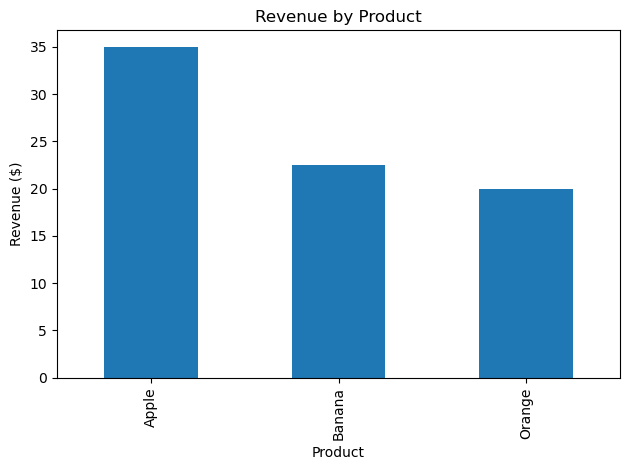

In [31]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

def main():
    # 1. Connect to (or create) the SQLite database
    conn = sqlite3.connect("sales_data.db")
    cursor = conn.cursor()

    # 2. Ensure the 'sales' table exists
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS sales (
        id       INTEGER PRIMARY KEY AUTOINCREMENT,
        product  TEXT,
        quantity INTEGER,
        price    REAL
    )
    """)
    conn.commit()

    # 3. (Optional) Insert sample data on first run—comment out after initial run
    sample_data = [
        ("Apple", 10, 0.5),
        ("Banana",  5, 0.3),
        ("Orange",  7, 0.4),
        ("Apple",   4, 0.5),
        ("Banana", 10, 0.3),
        ("Orange",  3, 0.4)
    ]
    cursor.executemany(
        "INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)",
        sample_data
    )
    conn.commit()

    # 4. Run the aggregation SQL query
    query = """
    SELECT
        product,
        SUM(quantity)         AS total_qty,
        SUM(quantity * price) AS revenue
    FROM sales
    GROUP BY product
    """
    df = pd.read_sql_query(query, conn)

    # 5. Print the DataFrame
    print("Sales Summary:\n")
    print(df.to_string(index=False))

    # 6. Plot revenue by product as a bar chart
    ax = df.plot(kind='bar', x='product', y='revenue', legend=False)
    ax.set_title("Revenue by Product")
    ax.set_xlabel("Product")
    ax.set_ylabel("Revenue ($)")
    plt.tight_layout()

    # 7. Save and show the chart
    plt.savefig("sales_chart.png")
    plt.show()

    # 8. Clean up
    conn.close()

if __name__ == "__main__":
    main()
